In [1]:
import gensim.downloader as api
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [51]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-50")
print("Số lượng từ trong vocab:", len(model.key_to_index))
print("Kích thước vector:", model.vector_size)

print(model["king"][:10])   


Số lượng từ trong vocab: 400000
Kích thước vector: 50
[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012 ]


In [46]:
vec_king = model['king']
similar = model.most_similar('king', topn=1000)
words = ['king'] + [w for w,_ in similar]
vectors = [model[w] for w in words]


In [40]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(vectors)

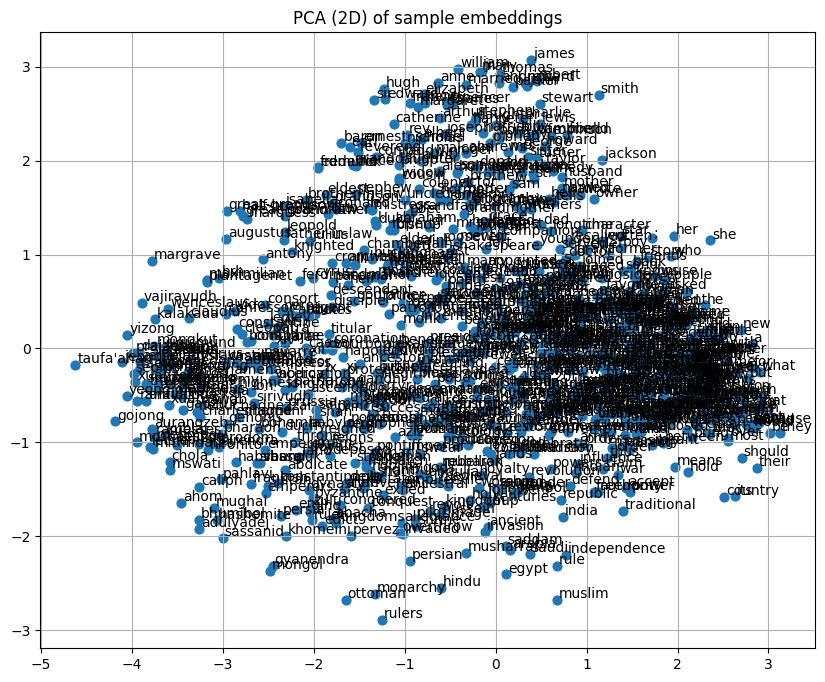

In [41]:
plt.figure(figsize=(10,8))
plt.scatter(pca_result[:,0], pca_result[:,1], s=40)
for i,w in enumerate(words):
    plt.annotate(w, (pca_result[i,0]+0.02, pca_result[i,1]+0.02))
plt.title("PCA (2D) of sample embeddings")
plt.grid(True)
plt.show()

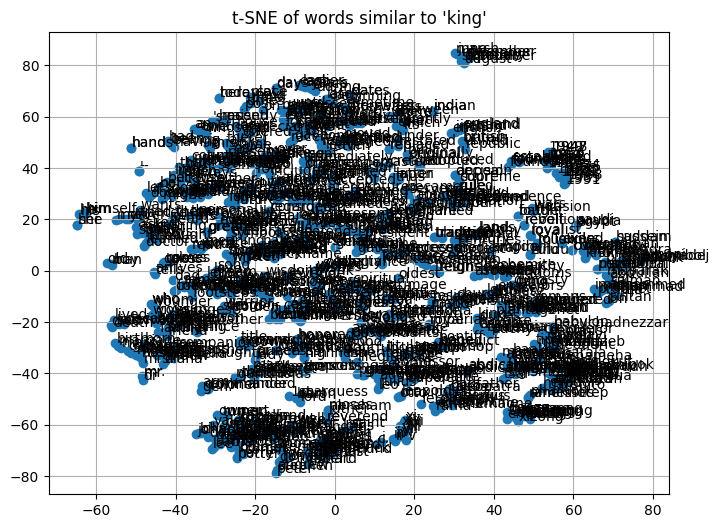

In [55]:
similar = model.most_similar("king", topn=1000)
words = ["king"] + [w for w,_ in similar]

vectors = np.array([model[w] for w in words])

tsne = TSNE(n_components=2, perplexity=5, max_iter=1000, random_state=42, init='random')
X_tsne = tsne.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1])
for i,w in enumerate(words):
    plt.annotate(w, (X_tsne[i,0]+0.2, X_tsne[i,1]+0.2))
plt.title("t-SNE of words similar to 'king'")
plt.grid(True)
plt.show()
